# FIFA Player Performance Prediction Using Data Mining

**Eyad Kathir**  
**CST 6307 – Data Mining**  
**Instructor: Dr. Adeel Malik**

This notebook is designed to fully support the project report and presentation. It:
- loads all 3 FIFA datasets
- standardizes different column names into one shared schema
- cleans each dataset safely
- runs regression, classification, clustering, and cross-dataset comparison
- saves visuals and outputs for the final report




In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the three datasets

- `fifa_players.csv`
- `FIFA-Players-Dataset.csv`
- `FIFA-PLAYER-DATA-SET&SEASON-STATS.csv`


In [37]:
file_1 = "fifa_players.csv"
file_2 = "FIFA-Players-Dataset.csv"
file_3 = "FIFA-PLAYER-DATA-SET&SEASON-STATS.csv"

df1 = pd.read_csv(file_1, low_memory=False)
df2 = pd.read_csv(file_2, low_memory=False)
df3 = pd.read_csv(file_3, low_memory=False)

print("Dataset shapes:")
print(f"{file_1}: {df1.shape}")
print(f"{file_2}: {df2.shape}")
print(f"{file_3}: {df3.shape}")

Dataset shapes:
fifa_players.csv: (17954, 51)
FIFA-Players-Dataset.csv: (16155, 110)
FIFA-PLAYER-DATA-SET&SEASON-STATS.csv: (28436, 135)


In [38]:
print("fifa_players.csv columns:")
print(df1.columns.tolist())

print("\nFIFA-Players-Dataset.csv columns:")
print(df2.columns.tolist()[:40], "...")

print("\nFIFA-PLAYER-DATA-SET&SEASON-STATS.csv columns:")
print(df3.columns.tolist()[:40], "...")

fifa_players.csv columns:
['name', 'full_name', 'birth_date', 'age', 'height_cm', 'weight_kgs', 'positions', 'nationality', 'overall_rating', 'potential', 'value_euro', 'wage_euro', 'preferred_foot', 'international_reputation(1-5)', 'weak_foot(1-5)', 'skill_moves(1-5)', 'body_type', 'release_clause_euro', 'national_team', 'national_rating', 'national_team_position', 'national_jersey_number', 'crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys', 'dribbling', 'curve', 'freekick_accuracy', 'long_passing', 'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots', 'aggression', 'interceptions', 'positioning', 'vision', 'penalties', 'composure', 'marking', 'standing_tackle', 'sliding_tackle']

FIFA-Players-Dataset.csv columns:
['sofifa_id', 'player_url', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg',

## 2. Standardize column names

The three datasets use different column names such as:
- `overall_rating` vs `overall`
- `value_euro` vs `value_eur`
- `wage_euro` vs `wage_eur`
- `age_fifa` vs `age`

This step normalizes them into one shared schema.


In [8]:
def standardize_dataset(df, dataset_name):
    df = df.copy()
    rename_map = {}

    if "overall_rating" in df.columns:
        rename_map["overall_rating"] = "overall"
    if "age_fifa" in df.columns:
        rename_map["age_fifa"] = "age"
    if "value_euro" in df.columns:
        rename_map["value_euro"] = "value_eur"
    if "wage_euro" in df.columns:
        rename_map["wage_euro"] = "wage_eur"
    if "release_clause_euro" in df.columns:
        rename_map["release_clause_euro"] = "release_clause_eur"

    if "short_passing" in df.columns and "passing" not in df.columns:
        rename_map["short_passing"] = "passing"
    if "standing_tackle" in df.columns and "defending" not in df.columns:
        rename_map["standing_tackle"] = "defending"

    df = df.rename(columns=rename_map)

    print(f"\n{dataset_name} standardized.")
    print("Sample standardized columns:", df.columns.tolist()[:25])
    return df

df1_std = standardize_dataset(df1, file_1)
df2_std = standardize_dataset(df2, file_2)
df3_std = standardize_dataset(df3, file_3)


fifa_players.csv standardized.
Sample standardized columns: ['name', 'full_name', 'birth_date', 'age', 'height_cm', 'weight_kgs', 'positions', 'nationality', 'overall', 'potential', 'value_eur', 'wage_eur', 'preferred_foot', 'international_reputation(1-5)', 'weak_foot(1-5)', 'skill_moves(1-5)', 'body_type', 'release_clause_eur', 'national_team', 'national_rating', 'national_team_position', 'national_jersey_number', 'crossing', 'finishing', 'heading_accuracy']

FIFA-Players-Dataset.csv standardized.
Sample standardized columns: ['sofifa_id', 'player_url', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_name', 'league_level', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined', 'club_contract_valid_until', 'nationality_id', 'nationality_name', 'nation_team_id']

FIFA-PLAYER-DATA-SET&SEASON-STATS.csv standardized.
Sample standardized columns: [

## 3. Define shared modeling features

These are the safest common columns across the three datasets.


In [9]:
common_features = [
    "age",
    "potential",
    "value_eur",
    "wage_eur",
    "dribbling",
    "reactions",
    "stamina",
    "strength",
    "interceptions",
    "vision",
    "composure"
]

target = "overall"

print("Common target:", target)
print("Common feature candidates:", common_features)

Common target: overall
Common feature candidates: ['age', 'potential', 'value_eur', 'wage_eur', 'dribbling', 'reactions', 'stamina', 'strength', 'interceptions', 'vision', 'composure']


## 4. Clean each dataset safely

This step:
- keeps only available shared features
- converts them to numeric
- drops rows missing the target
- fills missing feature values with the median


In [10]:
def prepare_dataset(df, dataset_name, features, target):
    df = df.copy()
    available_features = [col for col in features if col in df.columns]

    if target not in df.columns:
        print(f"{dataset_name}: target '{target}' not found.")
        return None, None

    temp_df = df[available_features + [target]].copy()

    for col in available_features + [target]:
        temp_df[col] = pd.to_numeric(temp_df[col], errors="coerce")

    temp_df = temp_df.dropna(subset=[target])

    for col in available_features:
        temp_df[col] = temp_df[col].fillna(temp_df[col].median())

    print(f"\n{dataset_name}")
    print("Rows used:", len(temp_df))
    print("Features used:", available_features)
    print("Missing values after cleaning:")
    print(temp_df.isnull().sum())

    return temp_df, available_features

df1_clean, df1_features = prepare_dataset(df1_std, file_1, common_features, target)
df2_clean, df2_features = prepare_dataset(df2_std, file_2, common_features, target)
df3_clean, df3_features = prepare_dataset(df3_std, file_3, common_features, target)


fifa_players.csv
Rows used: 17954
Features used: ['age', 'potential', 'value_eur', 'wage_eur', 'dribbling', 'reactions', 'stamina', 'strength', 'interceptions', 'vision', 'composure']
Missing values after cleaning:
age              0
potential        0
value_eur        0
wage_eur         0
dribbling        0
reactions        0
stamina          0
strength         0
interceptions    0
vision           0
composure        0
overall          0
dtype: int64

FIFA-Players-Dataset.csv
Rows used: 16155
Features used: ['age', 'potential', 'value_eur', 'wage_eur', 'dribbling']
Missing values after cleaning:
age          0
potential    0
value_eur    0
wage_eur     0
dribbling    0
overall      0
dtype: int64

FIFA-PLAYER-DATA-SET&SEASON-STATS.csv
Rows used: 28436
Features used: ['age', 'potential', 'value_eur', 'wage_eur', 'dribbling']
Missing values after cleaning:
age          0
potential    0
value_eur    0
wage_eur     0
dribbling    0
overall      0
dtype: int64


## 5. Choose the primary dataset for deeper analysis

The main modeling dataset will be `FIFA-Players-Dataset.csv` because it usually has the cleanest overall schema for the main workflow.


In [11]:
model_df = df2_clean.copy()
features = df2_features.copy()

print("Primary dataset:", file_2)
print("Shape:", model_df.shape)
print("Features:", features)
display(model_df.head())

Primary dataset: FIFA-Players-Dataset.csv
Shape: (16155, 6)
Features: ['age', 'potential', 'value_eur', 'wage_eur', 'dribbling']


,age,potential,value_eur,wage_eur,dribbling,overall
0,27,95,100500000.0,550000.0,96.0,93
1,29,92,79000000.0,375000.0,91.0,92
2,30,90,54500000.0,275000.0,92.0,90
3,32,90,52500000.0,275000.0,86.0,90
4,28,90,63500000.0,300000.0,62.0,90


## 6. Add engineered features safely



In [12]:
def add_engineered_features(df):
    df = df.copy()

    possible_technical = [
        "dribbling", "vision", "composure",
        "passing", "short_passing", "long_passing",
        "ball_control", "crossing", "finishing"
    ]
    technical_parts = [col for col in possible_technical if col in df.columns]
    print("technical parts found:", technical_parts)

    if len(technical_parts) >= 2:
        df["technical_score"] = df[technical_parts].mean(axis=1)
    elif len(technical_parts) == 1:
        df["technical_score"] = df[technical_parts[0]]
    else:
        df["technical_score"] = np.nan

    if "value_eur" in df.columns and "wage_eur" in df.columns:
        df["value_per_wage"] = df["value_eur"] / (df["wage_eur"] + 1)
    else:
        df["value_per_wage"] = np.nan

    if "potential" in df.columns and "overall" in df.columns:
        df["age_potential_gap"] = df["potential"] - df["overall"]
    else:
        df["age_potential_gap"] = np.nan

    return df

model_df = add_engineered_features(model_df)

engineered_features = features.copy()
for col in ["technical_score", "value_per_wage", "age_potential_gap"]:
    if col in model_df.columns and model_df[col].notna().sum() > 0:
        engineered_features.append(col)

print("Final engineered features:", engineered_features)
display(model_df.head())

technical parts found: ['dribbling']
Final engineered features: ['age', 'potential', 'value_eur', 'wage_eur', 'dribbling', 'technical_score', 'value_per_wage', 'age_potential_gap']


,age,potential,value_eur,wage_eur,dribbling,overall,technical_score,value_per_wage,age_potential_gap
0,27,95,100500000.0,550000.0,96.0,93,96.0,182.726940,2
1,29,92,79000000.0,375000.0,91.0,92,91.0,210.666105,0
2,30,90,54500000.0,275000.0,92.0,90,92.0,198.181098,0
3,32,90,52500000.0,275000.0,86.0,90,86.0,190.908397,0
4,28,90,63500000.0,300000.0,62.0,90,62.0,211.665961,0


## 7. Exploratory data analysis

In [13]:
print("Summary statistics:")
display(model_df.describe())

Summary statistics:


,age,potential,value_eur,wage_eur,dribbling,overall,technical_score,value_per_wage,age_potential_gap
count,16155.000000,16155.000000,1.615500e+04,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000
mean,24.776230,68.350108,1.067620e+06,13130.424017,60.687651,63.830393,60.687651,71.659299,4.519715
std,4.625321,6.580610,2.817001e+06,23454.795053,10.160870,7.169896,10.160870,45.155300,4.341342
min,16.000000,40.000000,1.000000e+03,2000.000000,25.000000,40.000000,25.000000,0.049998,0.000000
25%,21.000000,64.000000,1.300000e+05,2000.000000,55.000000,59.000000,55.000000,45.990802,0.000000
50%,24.000000,68.000000,3.500000e+05,5000.000000,62.000000,64.000000,62.000000,64.996750,4.000000
75%,28.000000,73.000000,8.250000e+05,10000.000000,67.000000,68.000000,67.000000,87.485419,7.000000
max,44.000000,95.000000,1.005000e+08,550000.000000,96.000000,93.000000,96.000000,1599.200400,28.000000


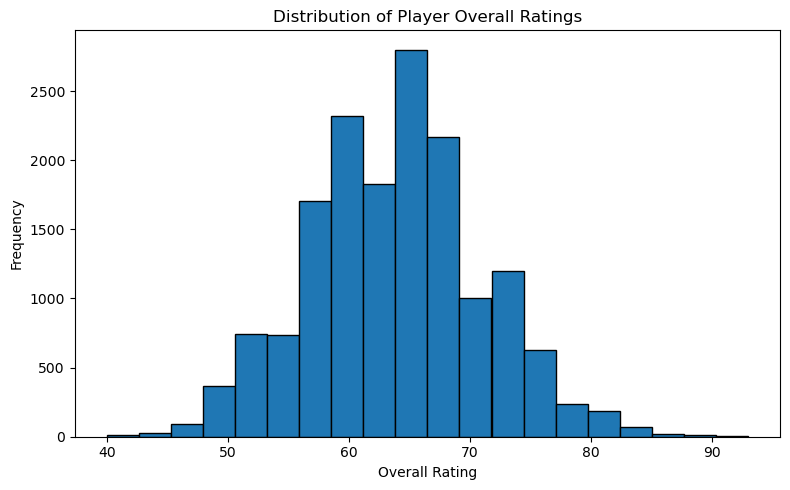

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(model_df["overall"], bins=20, edgecolor="black")
plt.title("Distribution of Player Overall Ratings")
plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=300)
plt.show()

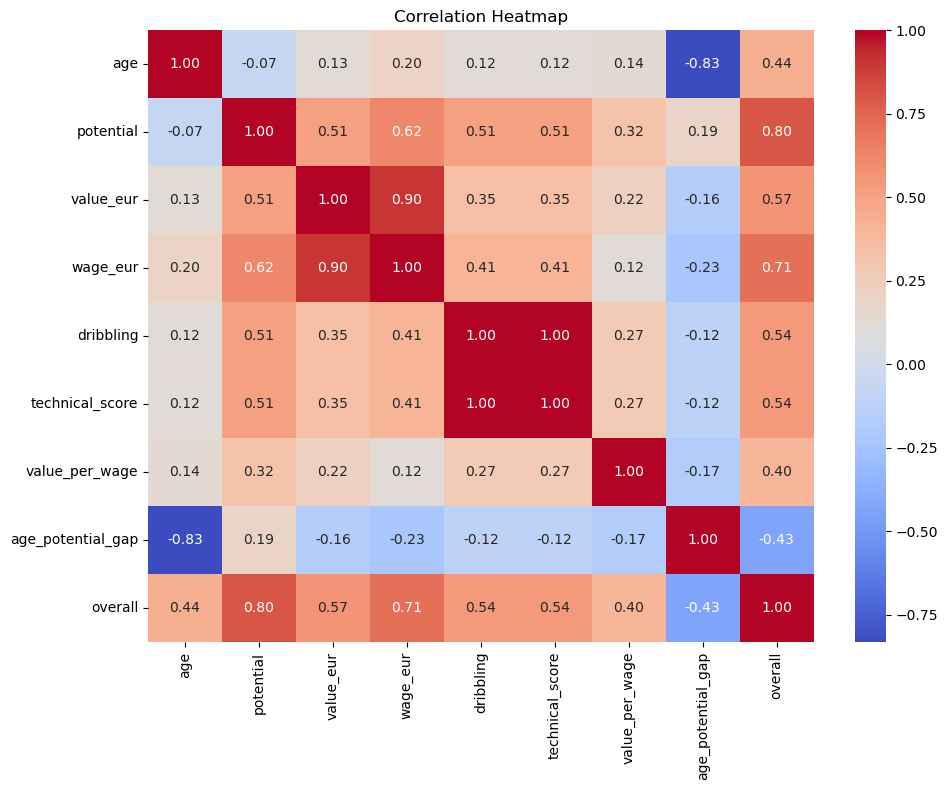

In [15]:
corr = model_df[engineered_features + [target]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

## 8. Train/test split for regression

In [16]:
X = model_df[engineered_features].copy()
y = model_df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (12924, 8)
Testing shape: (3231, 8)


## 9. Regression models

In [17]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("RMSE:", round(lr_rmse, 3))
print("MAE :", round(lr_mae, 3))
print("R2  :", round(lr_r2, 3))

Linear Regression
RMSE: 0.0
MAE : 0.0
R2  : 1.0


In [18]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("RMSE:", round(ridge_rmse, 3))
print("MAE :", round(ridge_mae, 3))
print("R2  :", round(ridge_r2, 3))

Ridge Regression
RMSE: 0.0
MAE : 0.0
R2  : 1.0


In [19]:
scaler_knn = MinMaxScaler()
X_train_knn = scaler_knn.fit_transform(X_train)
X_test_knn = scaler_knn.transform(X_test)

knn_model = KNeighborsRegressor(n_neighbors=7)
knn_model.fit(X_train_knn, y_train)
knn_pred = knn_model.predict(X_test_knn)

knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_mae = mean_absolute_error(y_test, knn_pred)
knn_r2 = r2_score(y_test, knn_pred)

print("KNN Regression")
print("RMSE:", round(knn_rmse, 3))
print("MAE :", round(knn_mae, 3))
print("R2  :", round(knn_r2, 3))

KNN Regression
RMSE: 0.73
MAE : 0.481
R2  : 0.99


In [20]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="r2")

print("Random Forest Regression")
print("RMSE:", round(rf_rmse, 3))
print("MAE :", round(rf_mae, 3))
print("R2  :", round(rf_r2, 3))
print("CV R2 scores:", rf_cv_scores)
print("Average CV R2:", round(rf_cv_scores.mean(), 3))

Random Forest Regression
RMSE: 0.464
MAE : 0.172
R2  : 0.996
CV R2 scores: [-1.3148014  -1.05319009 -0.59964765 -1.30753498 -1.8000597 ]
Average CV R2: -1.215


In [21]:
regression_results = pd.DataFrame([
    {"Model": "Linear Regression", "RMSE": round(lr_rmse, 3), "MAE": round(lr_mae, 3), "R2": round(lr_r2, 3)},
    {"Model": "Ridge Regression", "RMSE": round(ridge_rmse, 3), "MAE": round(ridge_mae, 3), "R2": round(ridge_r2, 3)},
    {"Model": "KNN Regression", "RMSE": round(knn_rmse, 3), "MAE": round(knn_mae, 3), "R2": round(knn_r2, 3)},
    {"Model": "Random Forest", "RMSE": round(rf_rmse, 3), "MAE": round(rf_mae, 3), "R2": round(rf_r2, 3)}
])

display(regression_results)
regression_results.to_csv("regression_results_summary.csv", index=False)

,Model,RMSE,MAE,R2
0,Linear Regression,0.000,0.000,1.000
1,Ridge Regression,0.000,0.000,1.000
2,KNN Regression,0.730,0.481,0.990
3,Random Forest,0.464,0.172,0.996


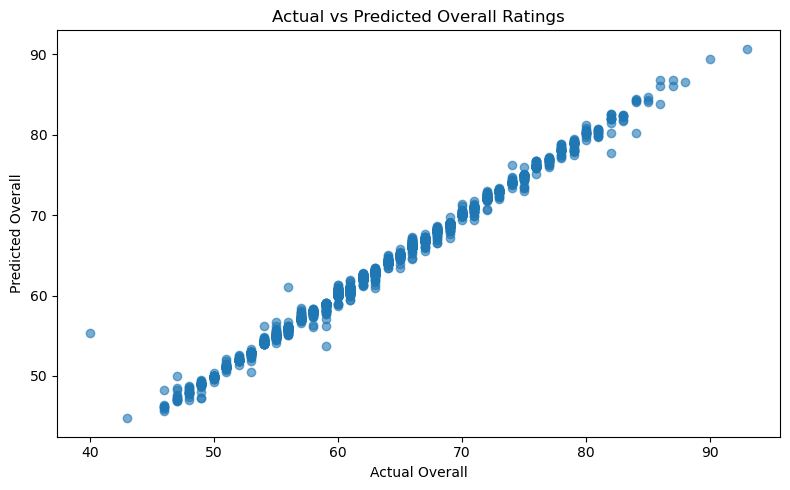

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.title("Actual vs Predicted Overall Ratings")
plt.xlabel("Actual Overall")
plt.ylabel("Predicted Overall")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=300)
plt.show()

,Feature,Importance
2,value_eur,0.785131
3,wage_eur,0.152250
0,age,0.026425
1,potential,0.025777
7,age_potential_gap,0.006153
6,value_per_wage,0.003072
4,dribbling,0.000618
5,technical_score,0.000574


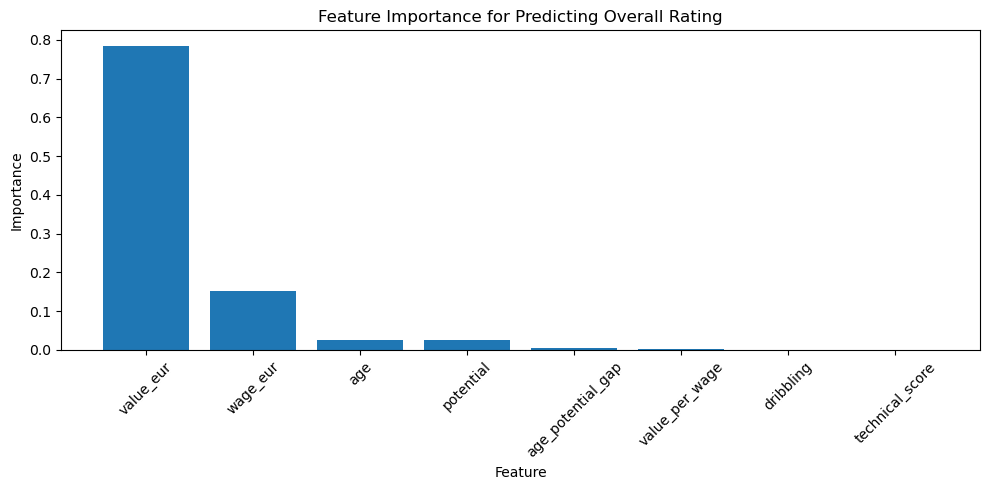

In [23]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance)
feature_importance.to_csv("feature_importance_output.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance for Predicting Overall Rating")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

## 10. Classification

In [24]:
def assign_tier(value):
    if value >= 85:
        return "Elite"
    elif value >= 75:
        return "Excellent"
    elif value >= 65:
        return "Good"
    elif value >= 55:
        return "Average"
    else:
        return "Below Average"

model_df["tier"] = model_df["overall"].apply(assign_tier)
print(model_df["tier"].value_counts())

tier
Average          7269
Good             6135
Below Average    1598
Excellent        1108
Elite              45
Name: count, dtype: int64


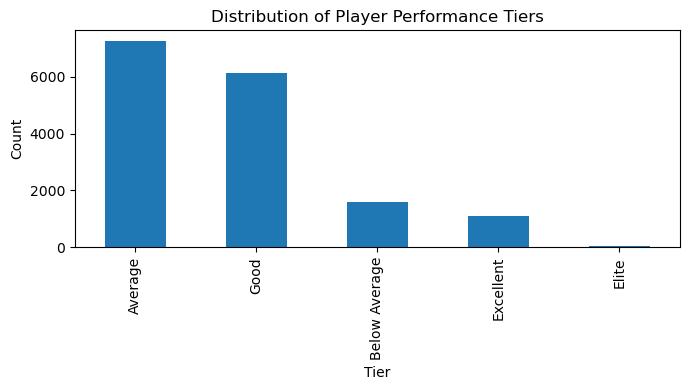

In [25]:
plt.figure(figsize=(7, 4))
model_df["tier"].value_counts().plot(kind="bar")
plt.title("Distribution of Player Performance Tiers")
plt.xlabel("Tier")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("tier_distribution.png", dpi=300)
plt.show()

In [26]:
X_class = model_df[engineered_features].copy()
y_class = model_df["tier"].copy()

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

log_model = LogisticRegression(max_iter=2000)
log_model.fit(Xc_train, yc_train)
log_pred = log_model.predict(Xc_test)
log_acc = accuracy_score(yc_test, log_pred)

clf_model = RandomForestClassifier(n_estimators=200, random_state=42)
clf_model.fit(Xc_train, yc_train)
clf_pred = clf_model.predict(Xc_test)
clf_acc = accuracy_score(yc_test, clf_pred)

print("Logistic Regression Accuracy:", round(log_acc, 3))
print("Random Forest Classification Accuracy:", round(clf_acc, 3))
print("\nClassification Report:")
print(classification_report(yc_test, clf_pred))

Logistic Regression Accuracy: 0.791
Random Forest Classification Accuracy: 0.969

Classification Report:
               precision    recall  f1-score   support

      Average       0.97      0.97      0.97      1454
Below Average       0.97      0.94      0.96       319
        Elite       1.00      0.89      0.94         9
    Excellent       0.96      0.95      0.95       222
         Good       0.97      0.98      0.97      1227

     accuracy                           0.97      3231
    macro avg       0.97      0.94      0.96      3231
 weighted avg       0.97      0.97      0.97      3231



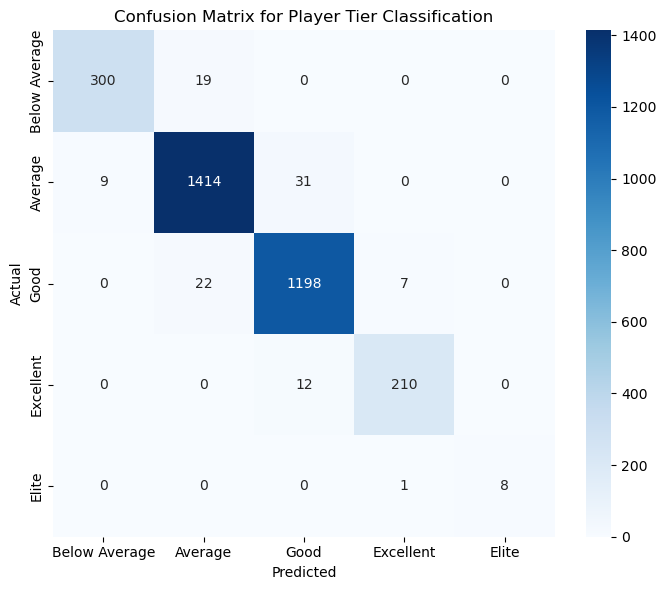

,Model,Accuracy
0,Logistic Regression,0.791
1,Random Forest Classifier,0.969


In [27]:
labels = ["Below Average", "Average", "Good", "Excellent", "Elite"]
cm = confusion_matrix(yc_test, clf_pred, labels=labels)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix for Player Tier Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

classification_results = pd.DataFrame([
    {"Model": "Logistic Regression", "Accuracy": round(log_acc, 3)},
    {"Model": "Random Forest Classifier", "Accuracy": round(clf_acc, 3)}
])

display(classification_results)
classification_results.to_csv("classification_results_summary.csv", index=False)

## 11. Clustering

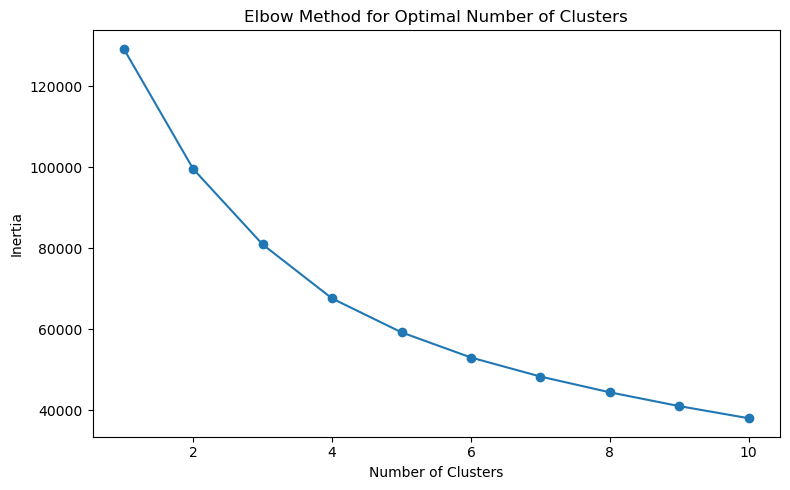

In [28]:
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(model_df[engineered_features])

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=300)
plt.show()

In [29]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
model_df["cluster"] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, model_df["cluster"])
print("Silhouette Score:", round(sil_score, 3))
print("\nCluster counts:")
print(model_df["cluster"].value_counts())

Silhouette Score: 0.258

Cluster counts:
cluster
0    5655
3    5050
1    3243
2    2068
4     139
Name: count, dtype: int64


In [30]:
cluster_summary = model_df.groupby("cluster")[engineered_features + ["overall"]].mean()
display(cluster_summary)
cluster_summary.to_csv("cluster_summary_output.csv")

,age,potential,value_eur,wage_eur,dribbling,technical_score,value_per_wage,age_potential_gap,overall
cluster,,,,,,,,,
0,28.687179,66.093899,5.950470e+05,8293.191866,62.666136,62.666136,82.886971,1.133864,64.960035
1,23.234351,63.278446,2.527644e+05,4482.886216,45.870490,45.870490,47.975439,5.254086,58.024360
2,26.043037,77.388781,3.926516e+06,49818.181818,72.354449,72.354449,79.561467,2.869923,74.518859
3,20.809109,69.960792,3.510228e+05,4947.920792,62.745743,62.745743,69.344059,8.597030,61.363762
4,26.920863,85.474820,2.280576e+07,163129.496403,77.546763,77.546763,133.994229,1.546763,83.928058


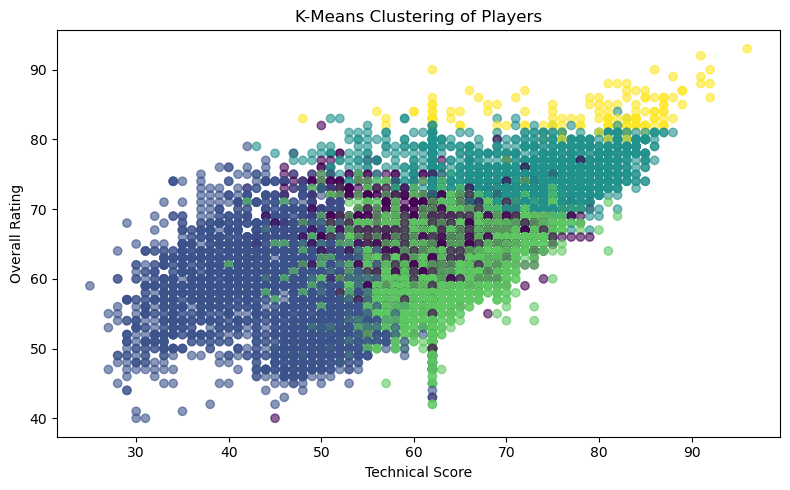

In [31]:
x_axis_col = "technical_score" if "technical_score" in model_df.columns else engineered_features[0]

plt.figure(figsize=(8, 5))
plt.scatter(
    model_df[x_axis_col],
    model_df["overall"],
    c=model_df["cluster"],
    alpha=0.6
)
plt.title("K-Means Clustering of Players")
plt.xlabel(x_axis_col.replace("_", " ").title())
plt.ylabel("Overall Rating")
plt.tight_layout()
plt.savefig("cluster_plot.png", dpi=300)
plt.show()

## 12. Cross-dataset comparison

This section runs the same Random Forest regression workflow across all 3 datasets using adaptive engineered features.


In [32]:
def evaluate_dataset(df, feature_list, dataset_name):
    temp = df.copy()
    temp = add_engineered_features(temp)

    extra_features = []
    for col in ["technical_score", "value_per_wage", "age_potential_gap"]:
        if col in temp.columns and temp[col].notna().sum() > 0:
            extra_features.append(col)

    final_features = feature_list + extra_features
    final_features = [col for col in final_features if col in temp.columns]

    X = temp[final_features].copy()
    y = temp["overall"].copy()

    for col in final_features:
        X[col] = pd.to_numeric(X[col], errors="coerce")
        X[col] = X[col].fillna(X[col].median())

    y = pd.to_numeric(y, errors="coerce")
    valid_idx = y.notna()
    X = X.loc[valid_idx]
    y = y.loc[valid_idx]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    return {
        "Dataset": dataset_name,
        "Rows Used": len(temp),
        "Features Used": len(final_features),
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3),
        "R2": round(r2, 3)
    }

In [33]:
comparison_results = []

if df1_clean is not None:
    comparison_results.append(evaluate_dataset(df1_clean, df1_features, file_1))

if df2_clean is not None:
    comparison_results.append(evaluate_dataset(df2_clean, df2_features, file_2))

if df3_clean is not None:
    comparison_results.append(evaluate_dataset(df3_clean, df3_features, file_3))

comparison_df = pd.DataFrame(comparison_results)
display(comparison_df)
comparison_df.to_csv("dataset_comparison_output.csv", index=False)

technical parts found: ['dribbling', 'vision', 'composure']
technical parts found: ['dribbling']
technical parts found: ['dribbling']


,Dataset,Rows Used,Features Used,RMSE,MAE,R2
0,fifa_players.csv,17954,14,0.322,0.142,0.998
1,FIFA-Players-Dataset.csv,16155,8,0.464,0.172,0.996
2,FIFA-PLAYER-DATA-SET&SEASON-STATS.csv,28436,8,0.273,0.109,0.998


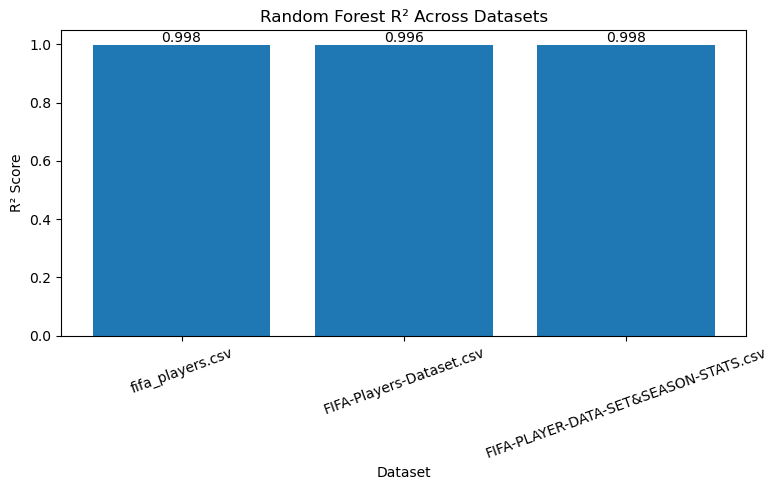

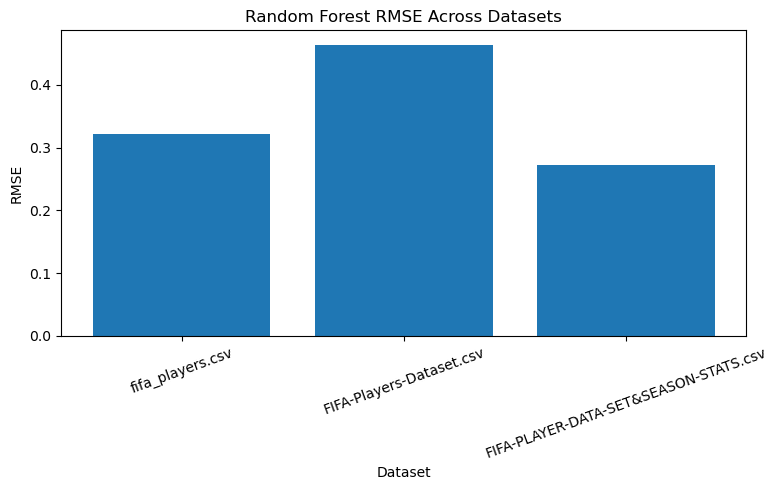

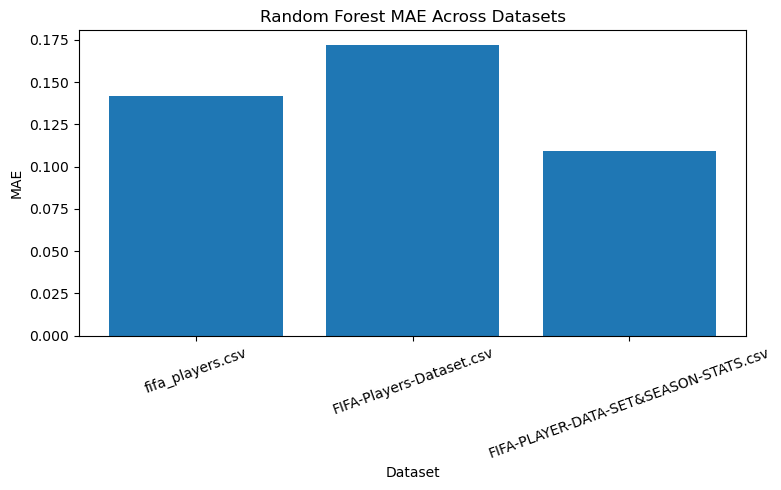

In [42]:
# R2 chart
plt.figure(figsize=(8, 5))
bars = plt.bar(comparison_df["Dataset"], comparison_df["R2"])
plt.title("Random Forest R² Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("R² Score")
plt.xticks(rotation=20)

for bar, val in zip(bars, comparison_df["R2"]):
    plt.text(bar.get_x() + bar.get_width()/2, val, f"{val:.3f}",
             ha="center", va="bottom")

plt.tight_layout()
plt.savefig("dataset_comparison_r2.png", dpi=300)
plt.show()

# RMSE chart
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Dataset"], comparison_df["RMSE"])
plt.title("Random Forest RMSE Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("dataset_comparison_rmse.png", dpi=300)
plt.show()

# MAE chart
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Dataset"], comparison_df["MAE"])
plt.title("Random Forest MAE Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("dataset_comparison_mae.png", dpi=300)
plt.show()

## 13. Save outputs

In [35]:
model_df.to_csv("processed_main_dataset.csv", index=False)

print("Saved files:")
print("- rating_distribution.png")
print("- correlation_heatmap.png")
print("- actual_vs_predicted.png")
print("- feature_importance.png")
print("- confusion_matrix.png")
print("- tier_distribution.png")
print("- elbow_plot.png")
print("- cluster_plot.png")
print("- dataset_comparison.png")
print("- regression_results_summary.csv")
print("- classification_results_summary.csv")
print("- feature_importance_output.csv")
print("- cluster_summary_output.csv")
print("- dataset_comparison_output.csv")
print("- processed_main_dataset.csv")

Saved files:
- rating_distribution.png
- correlation_heatmap.png
- actual_vs_predicted.png
- feature_importance.png
- confusion_matrix.png
- tier_distribution.png
- elbow_plot.png
- cluster_plot.png
- dataset_comparison.png
- regression_results_summary.csv
- classification_results_summary.csv
- feature_importance_output.csv
- cluster_summary_output.csv
- dataset_comparison_output.csv
- processed_main_dataset.csv


## 14. Final summary

This notebook covers:
- all 3 datasets
- schema standardization
- safe feature engineering
- regression
- classification
- clustering
- dataset comparison
- visuals and saved outputs for the report and presentation


In [36]:
print("FINAL PROJECT SUMMARY")
print("-" * 40)
print("Primary dataset:", file_2)
print("Best regression model: Random Forest")
print("Random Forest RMSE:", round(rf_rmse, 3))
print("Random Forest MAE:", round(rf_mae, 3))
print("Random Forest R2:", round(rf_r2, 3))
print("Random Forest CV R2:", round(rf_cv_scores.mean(), 3))
print("Random Forest classification accuracy:", round(clf_acc, 3))
print("Silhouette score:", round(sil_score, 3))
print("\nNotebook completed successfully.")

FINAL PROJECT SUMMARY
----------------------------------------
Primary dataset: FIFA-Players-Dataset.csv
Best regression model: Random Forest
Random Forest RMSE: 0.464
Random Forest MAE: 0.172
Random Forest R2: 0.996
Random Forest CV R2: -1.215
Random Forest classification accuracy: 0.969
Silhouette score: 0.258

Notebook completed successfully.
